# Inference Notebook
- This notebook imports a trained model and generates new samples.
- Edit the Checkpoint and Configs cell plus the sample-parameter cells to run your own inference.
- This version supports conditional generation for bass, guitar, and keyboard.
- Have fun creating new sounds!

*(NOTE: Do not use Run All in this notebook; run cells section-by-section.)*

#### Imports
Import necessary libraries to run the notebook

In [4]:
# Imports
import importlib
import matplotlib.pyplot as plt
import torch
import torchaudio
import IPython.display as ipd

import main.diffusion_module as diffusion_module
import main.inference_helpers as inference_helpers

diffusion_module = importlib.reload(diffusion_module)
inference_helpers = importlib.reload(inference_helpers)

load_inference_context = inference_helpers.load_inference_context
prepare_audio_for_display = inference_helpers.prepare_audio_for_display
plot_mel_spectrogram = inference_helpers.plot_mel_spectrogram
prepare_conditioning_inputs = inference_helpers.prepare_conditioning_inputs
resolve_reference_waveform = inference_helpers.resolve_reference_waveform
generate_unconditional_samples = inference_helpers.generate_unconditional_samples
generate_conditional_samples_from_reference = inference_helpers.generate_conditional_samples_from_reference
generate_class_conditioned_samples = inference_helpers.generate_class_conditioned_samples


### Checkpoint & Configs
- Replace these paths with the path to your model's checkpoint and configs.
- Pre-trained models are availlable to download on Hugging Face.

|Model|Link|
|---|---|
|Kicks|[crlandsc/tiny-audio-diffusion-kicks](https://huggingface.co/crlandsc/tiny-audio-diffusion-kicks)|
|Snares|[crlandsc/tiny-audio-diffusion-snares](https://huggingface.co/crlandsc/tiny-audio-diffusion-snares)|
|Hi-hats|[crlandsc/tiny-audio-diffusion-hihats](https://huggingface.co/crlandsc/tiny-audio-diffusion-hihats)|
|Percussion (all drum types)|[crlandsc/tiny-audio-diffusion-percussion](https://huggingface.co/crlandsc/tiny-audio-diffusion-percussion)|

In [2]:
# Inference settings mapped to scripts/train_conditional_models.sh runs
# - onehot: ConditionalModel + onehot + no contrastive
# - contrastive: EmbeddingConditionalModel + label_embedding + contrastive
model_variants = {
    "onehot": {
        "config_path": "exp/nsynth_conditional_16gb_no_wandb.yaml",
        "ckpt_path": "logs/ckpts/2026-04-19-17-22-41/epoch=141-valid_loss=0.033.ckpt",
        "conditioning_mode_override": "onehot",
    },
    "contrastive": {
        "config_path": "exp/nsynth_conditional_16gb_embedding_no_wandb.yaml",
        "ckpt_path": "logs/ckpts/epoch=16-valid_loss=0.027.ckpt",
        "conditioning_mode_override": "label_embedding",
    },
}

active_model = "contrastive"  # onehot | contrastive
if active_model not in model_variants:
    raise ValueError(f"Unknown active_model '{active_model}'. Use one of {list(model_variants.keys())}.")

config_path = model_variants[active_model]["config_path"]
ckpt_path = model_variants[active_model]["ckpt_path"]
conditioning_mode_override = model_variants[active_model].get("conditioning_mode_override")

# IMPORTANT: point this at the metadata jsonl used for this checkpoint's training.
# This is used to derive class names and for reference sampling.
metadata_path_override = "data/nsynth_waveform_box/metadata/metadata.jsonl"

# Leave as None to auto-select from metadata-derived class_names after context load.
reference_class_name = None
conditioning_class_name = None
reference_split = "test"             # train | valid | test
reference_index = None                # row index within the chosen split (e.g. test/40)

# Optional external reference waveform override for conditional input.
# Supports .wav/.flac/.mp3/.ogg/.m4a and .pt/.pth.
# Set to None to use datamodule sample selection instead.
reference_input_path = None

num_samples = 1
num_steps = 250
noise_scale = 0.5
unconditional_noise_scale = 0.3
seed = 2450

# Conditioning-difference magnifier settings.
conditioning_difference_gain = 10.0  # geometric exaggeration for plots/mix
difference_target_rms = 0.25         # loudness target for boosted delta playback
difference_playback_rate_scale = 0.75  # <1.0 slows playback to hear details
comparison_num_steps = num_steps
comparison_noise_scale = noise_scale

print("Active model:", active_model)
print("Config path:", config_path)
print("Checkpoint:", ckpt_path)
print("Conditioning mode override:", conditioning_mode_override)
print("Metadata path override:", metadata_path_override)
print("Reference class (pre-load):", reference_class_name)
print("Conditioning class (pre-load):", conditioning_class_name)
print("Reference split:", reference_split)
print("Reference index:", reference_index)
print("Reference input path:", reference_input_path)
print("Conditioning difference gain:", conditioning_difference_gain)
print("Difference target RMS:", difference_target_rms)
print("Difference playback rate scale:", difference_playback_rate_scale)


Active model: contrastive
Config path: exp/nsynth_conditional_16gb_embedding_no_wandb.yaml
Checkpoint: logs/ckpts/epoch=16-valid_loss=0.027.ckpt
Conditioning mode override: label_embedding
Metadata path override: data/nsynth_waveform_box/metadata/metadata.jsonl
Reference class (pre-load): None
Conditioning class (pre-load): None
Reference split: test
Reference index: None
Reference input path: None
Conditioning difference gain: 10.0
Difference target RMS: 0.25
Difference playback rate scale: 0.75


### Step 2: Load Inference Context
Load the selected checkpoint and config into a ready-to-sample context.

In [5]:
# Load the configured model and the conditional metadata-backed datamodule.
context = load_inference_context(
    config_path,
    ckpt_path,
    conditioning_mode_override=conditioning_mode_override,
    metadata_path_override=metadata_path_override,
)
model = context.model
datamodule = context.datamodule
class_names = context.class_names
conditioning_mode = context.conditioning_mode
conditioning_dim = context.conditioning_dim
sample_rate = context.sample_rate
sample_length = context.sample_length
audio_channels = context.audio_channels

if context.is_conditional and not class_names:
    raise ValueError(
        "No classes were resolved for conditional inference. "
        "Check metadata_path_override and metadata jsonl contents.",
    )

# Auto-pick labels from metadata-derived classes when not explicitly specified.
if class_names:
    if reference_class_name is None:
        reference_class_name = class_names[0]
    if conditioning_class_name is None:
        conditioning_class_name = class_names[1] if len(class_names) > 1 else class_names[0]

    if reference_class_name not in class_names:
        raise ValueError(f"reference_class_name '{reference_class_name}' must be one of {class_names}.")
    if conditioning_class_name not in class_names:
        raise ValueError(f"conditioning_class_name '{conditioning_class_name}' must be one of {class_names}.")

use_contrastive_loss = bool(context.config.get("model", {}).get("use_contrastive_loss", False))

print(f"Loaded variant: {active_model}")
print(f"Loaded config: {context.config_path}")
print(f"Conditional model: {context.is_conditional} | embedding model: {context.is_embedding_model}")
print(f"Conditioning mode: {conditioning_mode} | classes ({len(class_names)}): {class_names}")
print(f"Resolved reference class: {reference_class_name}")
print(f"Resolved conditioning class: {conditioning_class_name}")
print(f"Contrastive loss enabled in config: {use_contrastive_loss}")
print(f"Sample rate: {sample_rate} | length: {sample_length} | channels: {audio_channels}")
print(f"Metadata path used for datamodule: {context.metadata_path}")
print(f"Device: {model.device}")


Loaded variant: contrastive
Loaded config: exp/nsynth_conditional_16gb_embedding_no_wandb.yaml
Conditional model: True | embedding model: True
Conditioning mode: label_embedding | classes (7): ['bass', 'brass', 'guitar', 'keyboard', 'organ', 'reed', 'string']
Resolved reference class: bass
Resolved conditioning class: brass
Contrastive loss enabled in config: True
Sample rate: 16000 | length: 16384 | channels: 1
Metadata path used for datamodule: data/nsynth_waveform_box/metadata/metadata.jsonl
Device: cuda:0


In [6]:
# Runtime parameters summary.
sample_length = context.sample_length
sr = context.sample_rate
audio_channels = context.audio_channels

print("sample_length:", sample_length)
print("sr:", sr)
print("audio_channels:", audio_channels)
print("reference_input_path:", reference_input_path)
print("reference_class_name:", reference_class_name)
print("conditioning_class_name:", conditioning_class_name)
print("num_samples:", num_samples)
print("num_steps:", num_steps)
print("unconditional_noise_scale:", unconditional_noise_scale)
print("noise_scale:", noise_scale)
print("conditioning_difference_gain:", conditioning_difference_gain)
print("difference_target_rms:", difference_target_rms)
print("difference_playback_rate_scale:", difference_playback_rate_scale)


sample_length: 16384
sr: 16000
audio_channels: 1
reference_input_path: None
reference_class_name: bass
conditioning_class_name: brass
num_samples: 1
num_steps: 250
unconditional_noise_scale: 0.3
noise_scale: 0.5
conditioning_difference_gain: 10.0
difference_target_rms: 0.25
difference_playback_rate_scale: 0.75


In [7]:
# Conditional reference and class settings.
print("reference_class_name:", reference_class_name)
print("conditioning_class_name:", conditioning_class_name)
print("reference_split:", reference_split)
print("reference_index:", reference_index)
print("reference_input_path:", reference_input_path)
print("num_samples:", num_samples)
print("num_steps:", num_steps)
print("noise_scale:", noise_scale)


reference_class_name: bass
conditioning_class_name: brass
reference_split: test
reference_index: None
reference_input_path: None
num_samples: 1
num_steps: 250
noise_scale: 0.5


### Unconditional Generation
Run this cell to generate samples from pure noise (no class conditioning).

Active model: contrastive
Inference conditioning mode: label_embedding
Conditioning classes: ['bass', 'brass', 'guitar', 'keyboard', 'organ', 'reed', 'string']
Class-conditioned sample | class=bass | class_id=[0] | seed=2450 | steps=250 | noise_scale=0.3
  conditioning vector: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]


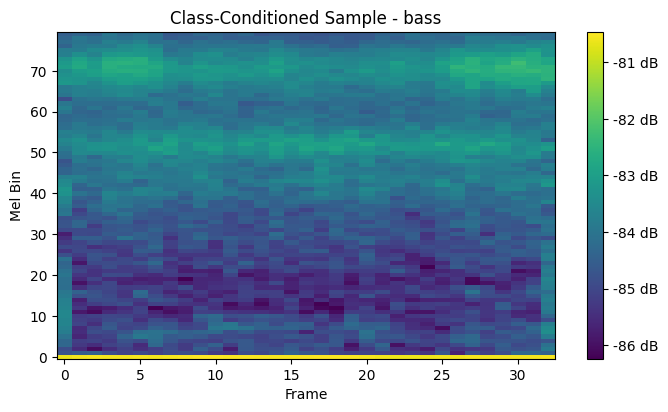

Class-conditioned sample | class=brass | class_id=[1] | seed=2450 | steps=250 | noise_scale=0.3
  conditioning vector: [[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]]


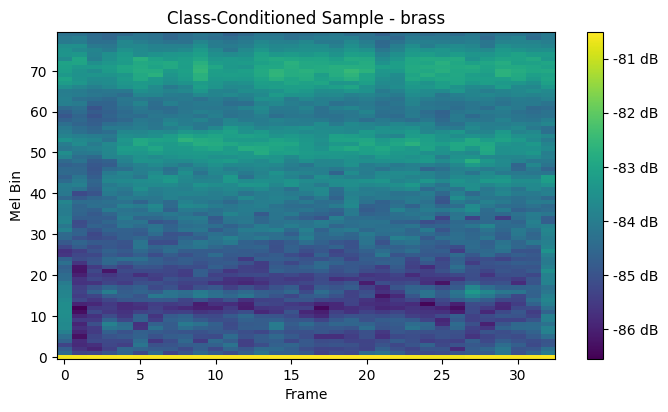

Class-conditioned sample | class=guitar | class_id=[2] | seed=2450 | steps=250 | noise_scale=0.3
  conditioning vector: [[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]]


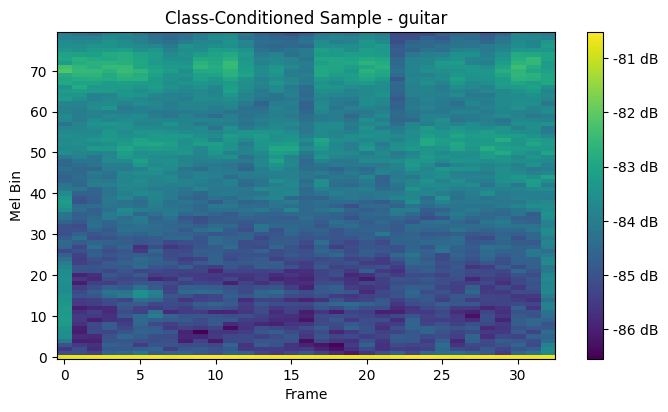

Class-conditioned sample | class=keyboard | class_id=[3] | seed=2450 | steps=250 | noise_scale=0.3
  conditioning vector: [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]]


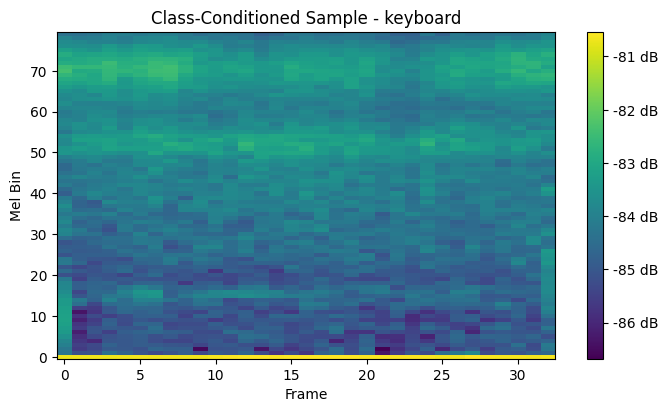

Class-conditioned sample | class=organ | class_id=[4] | seed=2450 | steps=250 | noise_scale=0.3
  conditioning vector: [[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]]


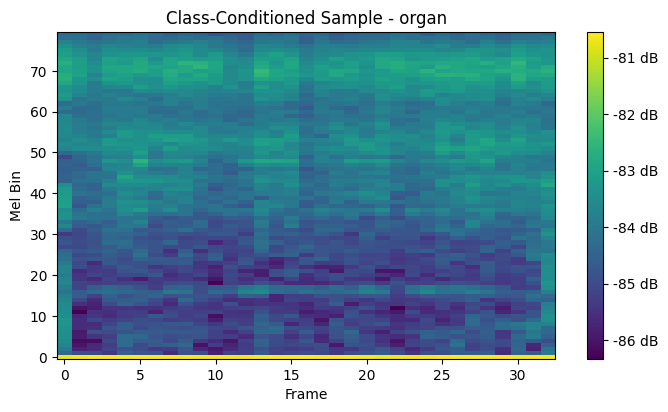

Class-conditioned sample | class=reed | class_id=[5] | seed=2450 | steps=250 | noise_scale=0.3
  conditioning vector: [[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]]


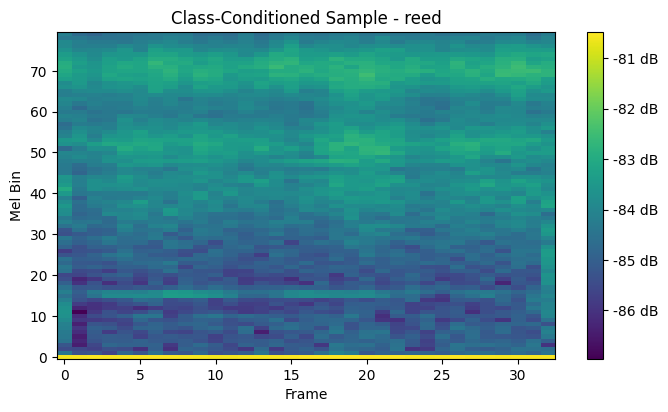

Class-conditioned sample | class=string | class_id=[6] | seed=2450 | steps=250 | noise_scale=0.3
  conditioning vector: [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]]


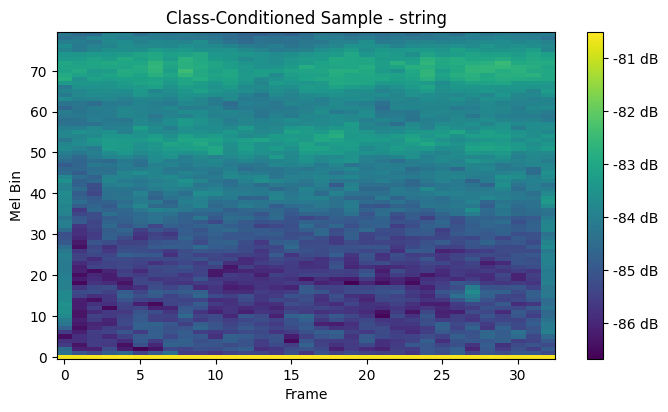

In [8]:
# Class-conditioned generation from pure noise.
# This is the no-reference version: we do not provide an input waveform here.
# Instead, we generate one sample for each class conditioning vector so you can hear what the model produces for each instrument class.
print(f"Active model: {active_model}")
print(f"Inference conditioning mode: {conditioning_mode}")
print(f"Conditioning classes: {class_names}")

for class_name in class_names:
    generated_samples, conditioning_info = generate_class_conditioned_samples(
        context,
        class_name,
        num_samples=1,
        num_steps=num_steps,
        seed=seed,
        noise_scale=unconditional_noise_scale,
    )

    generated_audio = prepare_audio_for_display(generated_samples[0])
    class_id = conditioning_info["class_ids"]
    conditioning_tensor = conditioning_info["conditioning"]

    print(f"Class-conditioned sample | class={class_name} | class_id={class_id.detach().cpu().tolist()} | seed={seed} | steps={num_steps} | noise_scale={unconditional_noise_scale}")
    if conditioning_tensor is not None:
        print(f"  conditioning vector: {conditioning_tensor.detach().cpu().tolist()}")
    else:
        print("  conditioning vector: None (label_embedding mode uses class_ids)")

    display(ipd.Audio(generated_audio.squeeze(0).numpy(), rate=sample_rate))
    plot_mel_spectrogram(generated_audio, sample_rate=sample_rate)
    plt.title(f"Class-Conditioned Sample - {class_name}")
    plt.show()


### Step 5: Conditional Generation
Generate class-conditioned outputs from a reference waveform, and display reference, noised input, and generated audio.

Active model: contrastive
Conditioning mode used for inference: label_embedding
Class id tensor: (1,) | values=[1]
Conditioning tensor: None (label_embedding mode uses class_ids)
Reference row class: bass
Reference clean path: /home/sammli/tiny-audio-diffusion/data/nsynth_waveform_box/waveforms/clean/test/bass/bass_synthetic_033-055-025.pt
Reference noisy path: None
Reference source: test/62
Reference class: bass
Conditioning class: brass
Reference clean input


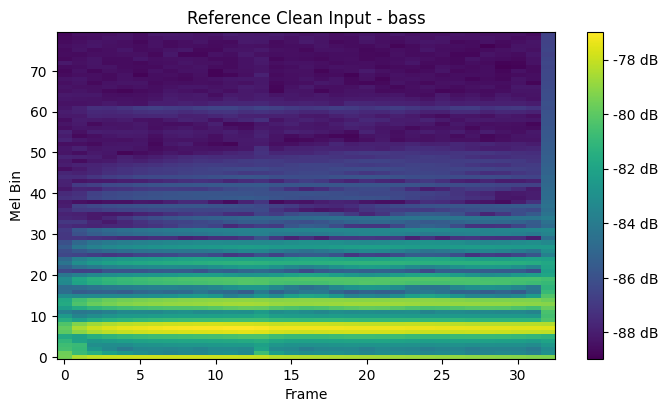

Actual conditional input to model (noised) - sample 1


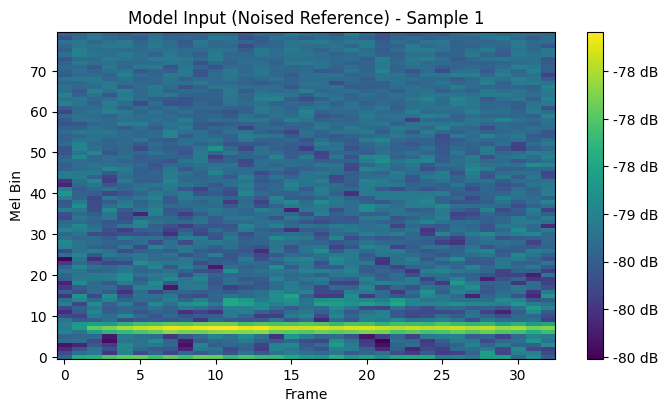

Generated sample 1 | ref=bass | cond=brass | mode=label_embedding


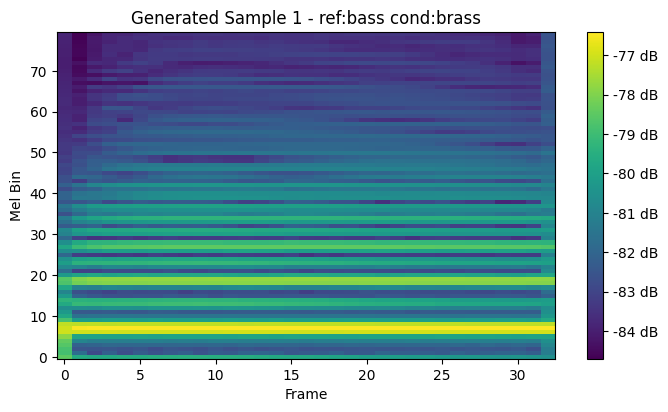

In [9]:
# Conditional generation only.
if context.datamodule is None and reference_input_path is None:
    raise ValueError("Set reference_input_path (.wav/.pt) or load a config with a conditional datamodule.")

class_id, conditioning_for_model = prepare_conditioning_inputs(context, conditioning_class_name)
print(f"Active model: {active_model}")
print(f"Conditioning mode used for inference: {conditioning_mode}")
print(f"Class id tensor: {tuple(class_id.shape)} | values={class_id.detach().cpu().tolist()}")
if conditioning_for_model is not None:
    print(f"Conditioning tensor: {tuple(conditioning_for_model.shape)}")
else:
    print("Conditioning tensor: None (label_embedding mode uses class_ids)")

seed_waveform, reference_label, reference_item = resolve_reference_waveform(
    context,
    class_name=reference_class_name,
    seed=seed,
    reference_split=reference_split,
    reference_index=reference_index,
    reference_input_path=reference_input_path,
)
if reference_item is not None:
    print(f"Reference row class: {reference_item['Class']}")
    print(f"Reference clean path: {reference_item.get('Clean Path')}")
    print(f"Reference noisy path: {reference_item.get('Noisy Path')}")

reference_audio = prepare_audio_for_display(seed_waveform)
print(f"Reference source: {reference_label}")
print(f"Reference class: {reference_class_name}")
print(f"Conditioning class: {conditioning_class_name}")

print("Reference clean input")
display(ipd.Audio(reference_audio.squeeze(0).numpy(), rate=sample_rate))
plot_mel_spectrogram(reference_audio, sample_rate=sample_rate)
plt.title(f"Reference Clean Input - {reference_class_name}")
plt.show()

conditional_results = generate_conditional_samples_from_reference(
    context,
    class_id=class_id,
    conditioning_for_model=conditioning_for_model,
    reference_waveform=reference_audio,
    num_samples=num_samples,
    num_steps=num_steps,
    seed=seed,
    noise_scale=noise_scale,
)

for sample_index, result in enumerate(conditional_results, start=1):
    model_input_audio = prepare_audio_for_display(result["model_input"])

    print(f"Actual conditional input to model (noised) - sample {sample_index}")
    display(ipd.Audio(model_input_audio.squeeze(0).numpy(), rate=sample_rate))
    plot_mel_spectrogram(model_input_audio, sample_rate=sample_rate)
    plt.title(f"Model Input (Noised Reference) - Sample {sample_index}")
    plt.show()

    generated_audio = prepare_audio_for_display(result["generated"])

    print(f"Generated sample {sample_index} | ref={reference_class_name} | cond={conditioning_class_name} | mode={conditioning_mode}")
    display(ipd.Audio(generated_audio.squeeze(0).numpy(), rate=sample_rate))
    plot_mel_spectrogram(generated_audio, sample_rate=sample_rate)
    plt.title(f"Generated Sample {sample_index} - ref:{reference_class_name} cond:{conditioning_class_name}")
    plt.show()


In [10]:
# Conditioning injection diagnostic: keep model input fixed and sweep conditioning labels.
# This directly tests whether changing conditioning_class_name changes the generated waveform.

from itertools import combinations

if context.datamodule is None and reference_input_path is None:
    raise ValueError("Set reference_input_path or use a config with a conditional datamodule before running diagnostics.")

# Resolve a single reference waveform (same source for all labels in this probe).
seed_waveform_diag, reference_label_diag, reference_item_diag = resolve_reference_waveform(
    context,
    class_name=reference_class_name,
    seed=seed,
    reference_split=reference_split,
    reference_index=reference_index,
    reference_input_path=reference_input_path,
)
reference_audio_diag = prepare_audio_for_display(seed_waveform_diag)
fixed_model_input = inference_helpers.build_noised_model_input(
    reference_audio_diag,
    model_device=model.device,
    seed=seed,
    noise_scale=noise_scale,
)

print("Diagnostic reference source:", reference_label_diag)
if reference_item_diag is not None:
    print("Diagnostic clean path:", reference_item_diag.get("Clean Path"))
print("Fixed model input seed:", seed)

results_by_label = {}
cond_vectors = {}
for label in class_names:
    class_id_diag, cond_for_model_diag = prepare_conditioning_inputs(context, label)
    # Explicitly inspect the conditioning vector that enters the model.
    cond_vec = context.model._encode_conditioning(cond_for_model_diag, class_id_diag).detach().cpu().squeeze(0)
    cond_vectors[label] = cond_vec

    generated_diag = inference_helpers.generate_conditional_sample_from_input(
        context,
        model_input=fixed_model_input,
        class_id=class_id_diag,
        conditioning_for_model=cond_for_model_diag,
        num_steps=num_steps,
    )
    results_by_label[label] = generated_diag
    print(f"Label {label}: class_id={class_id_diag.detach().cpu().tolist()} | cond_norm={cond_vec.norm().item():.6f}")

print("\nPairwise output deltas (same input noise, different labels):")
for a, b in combinations(class_names, 2):
    diff = results_by_label[a] - results_by_label[b]
    mse = torch.mean(diff ** 2).item()
    mae = torch.mean(torch.abs(diff)).item()
    max_abs = torch.max(torch.abs(diff)).item()
    print(f"{a:>8s} vs {b:<8s} | MSE={mse:.12e} | MAE={mae:.12e} | MAX={max_abs:.12e}")

print("\nPairwise conditioning-vector cosine similarity:")
for a, b in combinations(class_names, 2):
    cos = torch.nn.functional.cosine_similarity(
        cond_vectors[a].unsqueeze(0),
        cond_vectors[b].unsqueeze(0),
        dim=-1,
    ).item()
    print(f"{a:>8s} vs {b:<8s} | cosine={cos:.8f}")


Diagnostic reference source: test/62
Diagnostic clean path: /home/sammli/tiny-audio-diffusion/data/nsynth_waveform_box/waveforms/clean/test/bass/bass_synthetic_033-055-025.pt
Fixed model input seed: 2450
Label bass: class_id=[0] | cond_norm=0.975447
Label brass: class_id=[1] | cond_norm=0.914972
Label guitar: class_id=[2] | cond_norm=1.329628
Label keyboard: class_id=[3] | cond_norm=1.663353
Label organ: class_id=[4] | cond_norm=1.558179
Label reed: class_id=[5] | cond_norm=1.932237
Label string: class_id=[6] | cond_norm=1.254110

Pairwise output deltas (same input noise, different labels):
    bass vs brass    | MSE=2.532668411732e-03 | MAE=3.549449890852e-02 | MAX=2.997872233391e-01
    bass vs guitar   | MSE=1.960583264008e-03 | MAE=2.657659910619e-02 | MAX=2.787323296070e-01
    bass vs keyboard | MSE=7.460290216841e-04 | MAE=1.842413842678e-02 | MAX=3.019000291824e-01
    bass vs organ    | MSE=9.309108369052e-03 | MAE=7.603556662798e-02 | MAX=5.423574447632e-01
    bass vs reed  

### Conditioning Difference Magnifier
This section makes small conditioning differences easier to hear and inspect by comparing two labels on the exact same fixed model input.
It plays label A, label B, the boosted residual `(B - A) * gain`, and an exaggerated mix `A + gain * (B - A)`.

Reference source: test/62
Reference class: bass
Conditioning class: brass
MSE(ref,cond)=1.495108241215e-03 | MAE(ref,cond)=2.256404422224e-02 | MAX(ref,cond)=2.461116313934e-01
RMS(delta)=0.03866663 | RMS(reference)=1.11065817 | RMS(delta)/RMS(reference)=0.034814
Difference gain: 10.0x
Auto loudness gain for delta: 6.466x (16.21 dB)
Delta playback sample-rate for easier listening: 12000 Hz
Reference-conditioned output (bass)


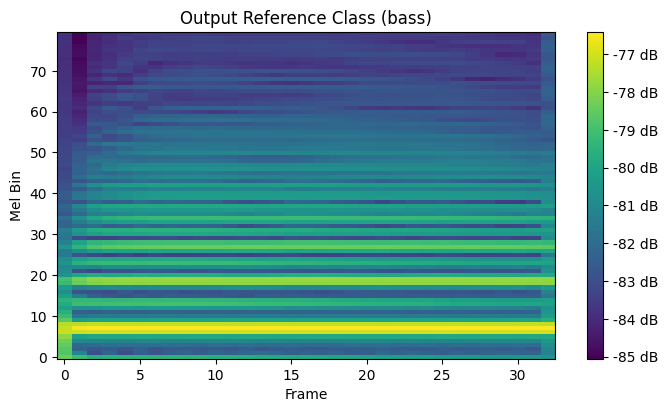

Target-conditioned output (brass)


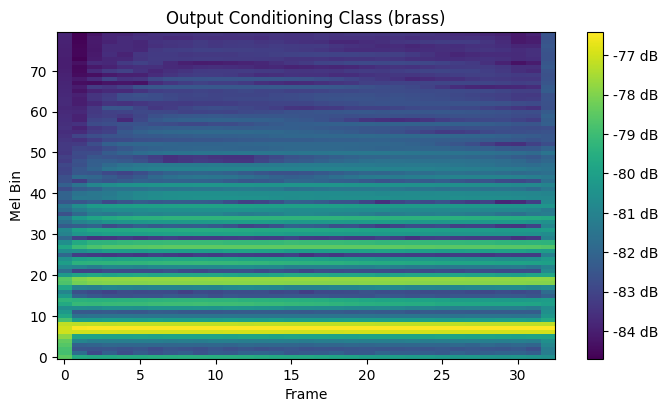

Boosted difference audio: conditioning - reference


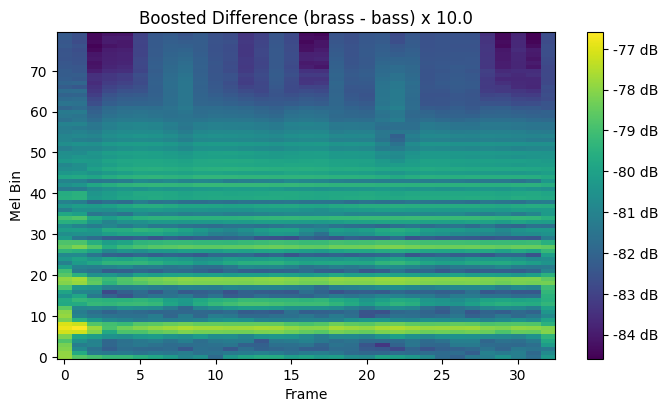

Auto-loud delta playback (RMS-normalized)


Auto-loud delta at slower playback rate


Exaggerated mix: reference + gain * (conditioning - reference)


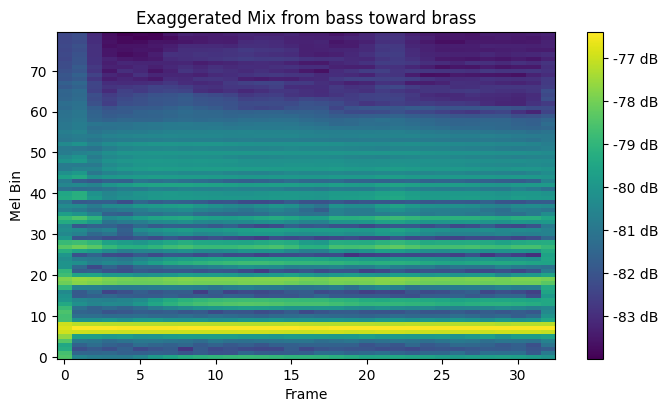

In [11]:
# Conditioning comparison on the same fixed input, with audible magnification of the delta.
if context.datamodule is None and reference_input_path is None:
    raise ValueError("Set reference_input_path or use a config with a conditional datamodule before running magnifier.")

if reference_class_name not in class_names or conditioning_class_name not in class_names:
    raise ValueError(f"Compare labels must be in {class_names}.")

seed_waveform_cmp, reference_label_cmp, _ = resolve_reference_waveform(
    context,
    class_name=reference_class_name,
    seed=seed,
    reference_split=reference_split,
    reference_index=reference_index,
    reference_input_path=reference_input_path,
)
reference_audio_cmp = prepare_audio_for_display(seed_waveform_cmp)
fixed_model_input_cmp = inference_helpers.build_noised_model_input(
    reference_audio_cmp,
    model_device=model.device,
    seed=seed,
    noise_scale=comparison_noise_scale,
 )

class_id_reference, cond_for_model_reference = prepare_conditioning_inputs(context, reference_class_name)
class_id_conditioning, cond_for_model_conditioning = prepare_conditioning_inputs(context, conditioning_class_name)

generated_reference = inference_helpers.generate_conditional_sample_from_input(
    context,
    model_input=fixed_model_input_cmp,
    class_id=class_id_reference,
    conditioning_for_model=cond_for_model_reference,
    num_steps=comparison_num_steps,
)
generated_conditioning = inference_helpers.generate_conditional_sample_from_input(
    context,
    model_input=fixed_model_input_cmp,
    class_id=class_id_conditioning,
    conditioning_for_model=cond_for_model_conditioning,
    num_steps=comparison_num_steps,
)

delta = generated_conditioning - generated_reference
delta_boosted = (delta * conditioning_difference_gain).clamp(-1.0, 1.0)
exaggerated_from_reference = (generated_reference + conditioning_difference_gain * delta).clamp(-1.0, 1.0)

mse_ab = torch.mean((generated_reference - generated_conditioning) ** 2).item()
mae_ab = torch.mean(torch.abs(generated_reference - generated_conditioning)).item()
max_ab = torch.max(torch.abs(generated_reference - generated_conditioning)).item()
rms_delta = torch.sqrt(torch.mean(delta ** 2)).item()
rms_reference = torch.sqrt(torch.mean(generated_reference ** 2)).item()
relative_delta = rms_delta / (rms_reference + 1e-8)

# Loudness-normalized difference audio makes small deltas easier to hear.
target_rms = float(max(difference_target_rms, 1e-4))
auto_gain = target_rms / (rms_delta + 1e-8)
delta_auto_loud = (delta * auto_gain).clamp(-1.0, 1.0)
auto_gain_db = 20.0 * torch.log10(torch.tensor(auto_gain)).item()
difference_playback_rate = max(1000, int(sample_rate * difference_playback_rate_scale))

print(f"Reference source: {reference_label_cmp}")
print(f"Reference class: {reference_class_name}")
print(f"Conditioning class: {conditioning_class_name}")
print(f"MSE(ref,cond)={mse_ab:.12e} | MAE(ref,cond)={mae_ab:.12e} | MAX(ref,cond)={max_ab:.12e}")
print(f"RMS(delta)={rms_delta:.8f} | RMS(reference)={rms_reference:.8f} | RMS(delta)/RMS(reference)={relative_delta:.6f}")
print(f"Difference gain: {conditioning_difference_gain}x")
print(f"Auto loudness gain for delta: {auto_gain:.3f}x ({auto_gain_db:.2f} dB)")
print(f"Delta playback sample-rate for easier listening: {difference_playback_rate} Hz")

print(f"Reference-conditioned output ({reference_class_name})")
display(ipd.Audio(prepare_audio_for_display(generated_reference).squeeze(0).numpy(), rate=sample_rate))
plot_mel_spectrogram(prepare_audio_for_display(generated_reference), sample_rate=sample_rate)
plt.title(f"Output Reference Class ({reference_class_name})")
plt.show()

print(f"Target-conditioned output ({conditioning_class_name})")
display(ipd.Audio(prepare_audio_for_display(generated_conditioning).squeeze(0).numpy(), rate=sample_rate))
plot_mel_spectrogram(prepare_audio_for_display(generated_conditioning), sample_rate=sample_rate)
plt.title(f"Output Conditioning Class ({conditioning_class_name})")
plt.show()

print("Boosted difference audio: conditioning - reference")
display(ipd.Audio(prepare_audio_for_display(delta_boosted).squeeze(0).numpy(), rate=sample_rate))
plot_mel_spectrogram(prepare_audio_for_display(delta_boosted), sample_rate=sample_rate)
plt.title(f"Boosted Difference ({conditioning_class_name} - {reference_class_name}) x {conditioning_difference_gain}")
plt.show()

print("Auto-loud delta playback (RMS-normalized)")
display(ipd.Audio(prepare_audio_for_display(delta_auto_loud).squeeze(0).numpy(), rate=sample_rate))
print("Auto-loud delta at slower playback rate")
display(ipd.Audio(prepare_audio_for_display(delta_auto_loud).squeeze(0).numpy(), rate=difference_playback_rate))

print("Exaggerated mix: reference + gain * (conditioning - reference)")
display(ipd.Audio(prepare_audio_for_display(exaggerated_from_reference).squeeze(0).numpy(), rate=sample_rate))
plot_mel_spectrogram(prepare_audio_for_display(exaggerated_from_reference), sample_rate=sample_rate)
plt.title(f"Exaggerated Mix from {reference_class_name} toward {conditioning_class_name}")
plt.show()
